# Setup

## Import packages

In [8]:
# === System & Utility ===
import os
import glob
import re
import time
import json
import math
import itertools
from dotenv import load_dotenv
import requests

# === Data Handling ===
import pandas as pd
import numpy as np
import geopandas as gpd

# === Geospatial & Location ===
import osmnx as ox
from shapely.geometry import Point
from shapely.wkt import dumps, loads
from geopy.geocoders import Nominatim

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# === Statistical Tools ===
from scipy import stats
from scipy.stats import norm, chi2_contingency, pointbiserialr

# === Preprocessing & Dimensionality Reduction ===
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# === Evaluation Metrics ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, make_scorer, roc_auc_score
)

# === Classification Models ===
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# === Regression Models ===
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# === Display Settings ===
pd.set_option('display.precision', 4)

## Self-defined functions

### plot_busyness_percentile_map

In [9]:
def plot_busyness_percentile_map(df, date_str, hour_int, busyness_level, ax=None, figsize=(6, 6), cmap='OrRd'):
    # 1. Filter data for the specified date and hour
    df_hour = df[(df['date'] == date_str) & (df['hour'] == hour_int)].copy()

    # 2. Convert to GeoDataFrame and reproject to Web Mercator
    gdf = gpd.GeoDataFrame(df_hour, geometry='geometry', crs='EPSG:4326').to_crs(epsg=3857)

    # 3. Drop rows with missing percentile values
    gdf = gdf.dropna(subset=[busyness_level])

    # 4. Prepare ax
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # 5. Plot the heatmap
    gdf.plot(
        ax=ax,
        column=busyness_level,
        cmap=cmap,
        linewidth=0.1,
        edgecolor='white',
        legend=True,
        legend_kwds={'title': busyness_level, 'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'}
    )

    ax.set_title(f"{busyness_level} - {date_str} {hour_int:02d}:00", fontsize=12)
    ax.axis("off")


### classification_evaluation

In [10]:
def classification_evaluation(y_actual, y_pred):
    """
    Prints a full evaluation report for multiclass classification results.

    Shows:
    - Accuracy
    - Precision (macro)
    - Recall (macro)
    - F1 score (macro)
    - Confusion matrix
    - Classification report

    Args:
        y_actual (array-like): True class labels
        y_pred (array-like): Predicted class labels
    """

    print("Accuracy       :", round(accuracy_score(y_actual, y_pred), 3))
    print("Precision Score:", round(precision_score(y_actual, y_pred, average='macro'), 3))
    print("Recall Score   :", round(recall_score(y_actual, y_pred, average='macro'), 3))
    print("F1 Score       :", round(f1_score(y_actual, y_pred, average='macro'), 3))
    print()

    # Confusion Matrix
    cm = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_actual, y_pred, zero_division=1))

### convert_percentile_to_level

In [11]:
def convert_percentile_to_level(series):
    """
    Convert continuous percentile values to 5-level categorical bins
    (equal-width binning from min to max).
    """
    min_val = series.min()
    max_val = series.max()
    bins = np.linspace(min_val, max_val, 6)  # 5 bins
    labels = ['1', '2', '3', '4', '5']

    result = pd.cut(
        series,
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    return result

### predict_sample_dataset

In [12]:
def predict_sample_dataset(model, input_X, input_y, 
                           sample_size=1000000, 
                           y_type='categorical', 
                           is_lgbm=False, is_cat=False,
                           eval_metric=None):
    """
    Train and evaluate a model on a sampled dataset.

    Parameters:
        model: sklearn, LightGBM, or CatBoost model
        input_X (DataFrame): feature set
        input_y (Series): target
        sample_size (int): max sample size
        y_type (str): 'continuous' or 'categorical'
        is_lgbm (bool): use LGBM-style training
        is_cat (bool): use CatBoost-style training
        eval_metric (str): metric for model evaluation
    """

    if y_type not in ['continuous', 'categorical']:
        raise ValueError('y_type must be "continuous" or "categorical"')

    # Sample
    X_sample = input_X.sample(n=min(sample_size, len(input_X)), random_state=42)
    y_sample = input_y.loc[X_sample.index]

    # Split
    stratify_arg = y_sample if y_type == 'categorical' else None
    X_train, X_test, y_train, y_test = train_test_split(
        X_sample, y_sample, test_size=0.3, stratify=stratify_arg, random_state=42
    )

    cat_features = X_sample.select_dtypes('category').columns.tolist()

    # Fit
    if not is_lgbm and not is_cat:
        model.fit(X_train, y_train)
    elif is_lgbm:
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            eval_metric=eval_metric,
            categorical_feature=cat_features,
            callbacks=[lgb.early_stopping(10)]
        )
    elif is_cat:
        model.fit(
            X_train, y_train,
            eval_set=(X_test, y_test),
            cat_features=cat_features)

    # Predict
    y_pred = model.predict(X_test)

    # Optional fix for CatBoost regression/classification float output
    if is_cat and y_type == 'categorical' and not np.issubdtype(y_pred.dtype, np.integer):
        y_pred = np.round(y_pred).astype(int)

    # Evaluate
    if y_type == 'continuous':
        y_test_label = convert_percentile_to_level(pd.Series(y_test).reset_index(drop=True))
        y_pred_label = convert_percentile_to_level(pd.Series(y_pred).reset_index(drop=True))
    else:
        y_test_label = y_test
        y_pred_label = y_pred

    classification_evaluation(y_test_label, y_pred_label)

# Busyness Score Exploration
- Compare different methods for generating the busyness score, and select the one that both performs best in the model and produces the most interpretable heatmap.

## Prepare dataset

In [13]:
# Load df
combined_df = pd.read_pickle("combined_light_with_busyness_level.pkl")

In [14]:
# Extract more date related data and convert them to category datatype
combined_df['grid_id'] = combined_df['grid_id'].astype('category')
combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df['month'] = combined_df['date'].dt.month.astype('category')
combined_df['weekofyear'] = combined_df['date'].dt.isocalendar().week.astype('category')
combined_df['dayofweek'] = combined_df['date'].dt.dayofweek.astype('category')
combined_df['is_weekend'] = combined_df['dayofweek'].astype('int') >= 5
combined_df['day'] = combined_df['date'].dt.day.astype('category')
combined_df['hour'] = combined_df['hour'].astype('category')
combined_df['is_holiday'] = combined_df['is_holiday'].astype('category')
combined_df['is_weekend'] = combined_df['is_weekend'].astype('category')

In [15]:
X_origin = combined_df[['month', 'weekofyear', 'dayofweek', 'is_weekend', 'day', 'hour', 'is_holiday', # time
                        'temp_c', 'dew_c', 'wind_speed_knot', 'precip_mm', # weather
                        'grid_id', 'restaurant_count', 'population', # grid info
                        'lat', 'lon', # could be removed
                        'event_count', # event
                       ]]

## Add computed busyness percentiles

In [16]:
traffic_cols = [
    'subway_grid_ridership', 'subway_buffer_ridership',
    'bike_grid_trips', 'bike_buffer_ridership',
    'taxi_passenger_count'
]

In [17]:
weights = [5, 3, 4, 2, 4]
weights = [w / sum(weights) for w in weights]

### -----------------------------
### 1. Z-score normalization
### -----------------------------
# Standardize each feature (mean=0, std=1)
scaler = StandardScaler()
combined_df[[f + '_z' for f in traffic_cols]] = scaler.fit_transform(combined_df[traffic_cols])

# Z-score equal-weight average
combined_df['busyness_zscore_avg'] = combined_df[[f + '_z' for f in traffic_cols]].mean(axis=1)
combined_df['busyness_zscore_avg_percentile'] = norm.cdf(combined_df['busyness_zscore_avg'])

# Z-score weighted average
combined_df['busyness_zscore_weighted'] = np.dot(combined_df[[f + '_z' for f in traffic_cols]].values, weights)
combined_df['busyness_zscore_weighted_percentile'] = norm.cdf(combined_df['busyness_zscore_weighted'])

### -----------------------------
### 2. MinMax normalization
### -----------------------------
# Scale features to [0, 1]
minmax = MinMaxScaler()
combined_df[[f + '_mm' for f in traffic_cols]] = minmax.fit_transform(combined_df[traffic_cols])

# MinMax equal-weight average
combined_df['busyness_minmax_avg'] = combined_df[[f + '_mm' for f in traffic_cols]].mean(axis=1)
combined_df['busyness_minmax_avg_percentile'] = combined_df['busyness_minmax_avg'].rank(pct=True)

# MinMax weighted average
combined_df['busyness_minmax_weighted'] = np.dot(combined_df[[f + '_mm' for f in traffic_cols]].values, weights)
combined_df['busyness_minmax_weighted_percentile'] = combined_df['busyness_minmax_weighted'].rank(pct=True)

### -----------------------------
### 3. PCA-based score
### -----------------------------
# Use the first principal component to summarize features
pca = PCA(n_components=1)
combined_df['busyness_pca'] = pca.fit_transform(combined_df[traffic_cols])[:, 0]
combined_df['busyness_pca_percentile'] = norm.cdf(combined_df['busyness_pca'])

### -----------------------------
### 4. Z-score summed percentile (Z → Sum → Z → CDF)
### -----------------------------
combined_df['busyness_score'] = combined_df[[f + '_z' for f in traffic_cols]].sum(axis=1)
score_scaler = StandardScaler()
combined_df['busyness_zscore'] = score_scaler.fit_transform(combined_df[['busyness_score']])
combined_df['busyness_percentile'] = norm.cdf(combined_df['busyness_zscore'])

### -----------------------------
### 5. Raw (unscaled) values
### -----------------------------
# Raw equal-weight average
combined_df['busyness_raw_avg'] = combined_df[traffic_cols].mean(axis=1)
combined_df['busyness_raw_avg_percentile'] = combined_df['busyness_raw_avg'].rank(pct=True)

# Raw weighted average
combined_df['busyness_raw_weighted'] = np.dot(combined_df[traffic_cols].values, weights)
combined_df['busyness_raw_weighted_percentile'] = combined_df['busyness_raw_weighted'].rank(pct=True)

In [18]:
busyness_percentile_cols = ['busyness_zscore_avg_percentile', 'busyness_zscore_weighted_percentile',
                            'busyness_minmax_avg_percentile', 'busyness_minmax_weighted_percentile',
                            'busyness_pca_percentile', 'busyness_percentile',
                            'busyness_raw_avg_percentile', 'busyness_raw_weighted_percentile']

# Compare on heatmap
To evaluate the spatial reasonableness of each busyness score, we make the following assumption:
    
    - At 12:00 PM, during peak lunch hours, city center areas should appear more busy, with a gradual fading of busyness toward the outer regions.
    - At 3:00 AM, the entire city should appear less busy overall.

We compare the heatmaps generated by each of the six scoring methods based on how well they align with this assumption:

- `busyness_zscore_avg_percentile`, `busyness_zscore_weighted_percentile`, `busyness_percentile`: Heatmaps at both noon and 3 AM generally align with expectations.

- `busyness_minmax_avg_percentile`, `busyness_minmax_weighted_percentile`, `busyness_raw_avg_percentile`, `busyness_raw_weighted_percentile`: At noon, almost the entire area is shown as busy. Even at 3 AM, many regions still appear overly busy, which seems less realistic.

- `busyness_pca_percentile`: Noon heatmap shows many regions as extremely busy, lacking a gradual spatial fade. The 3 AM pattern better matches expectations.

In [23]:
for col in busyness_percentile_cols:
    combined_df[f'{col}_level'] = convert_percentile_to_level(combined_df[col])

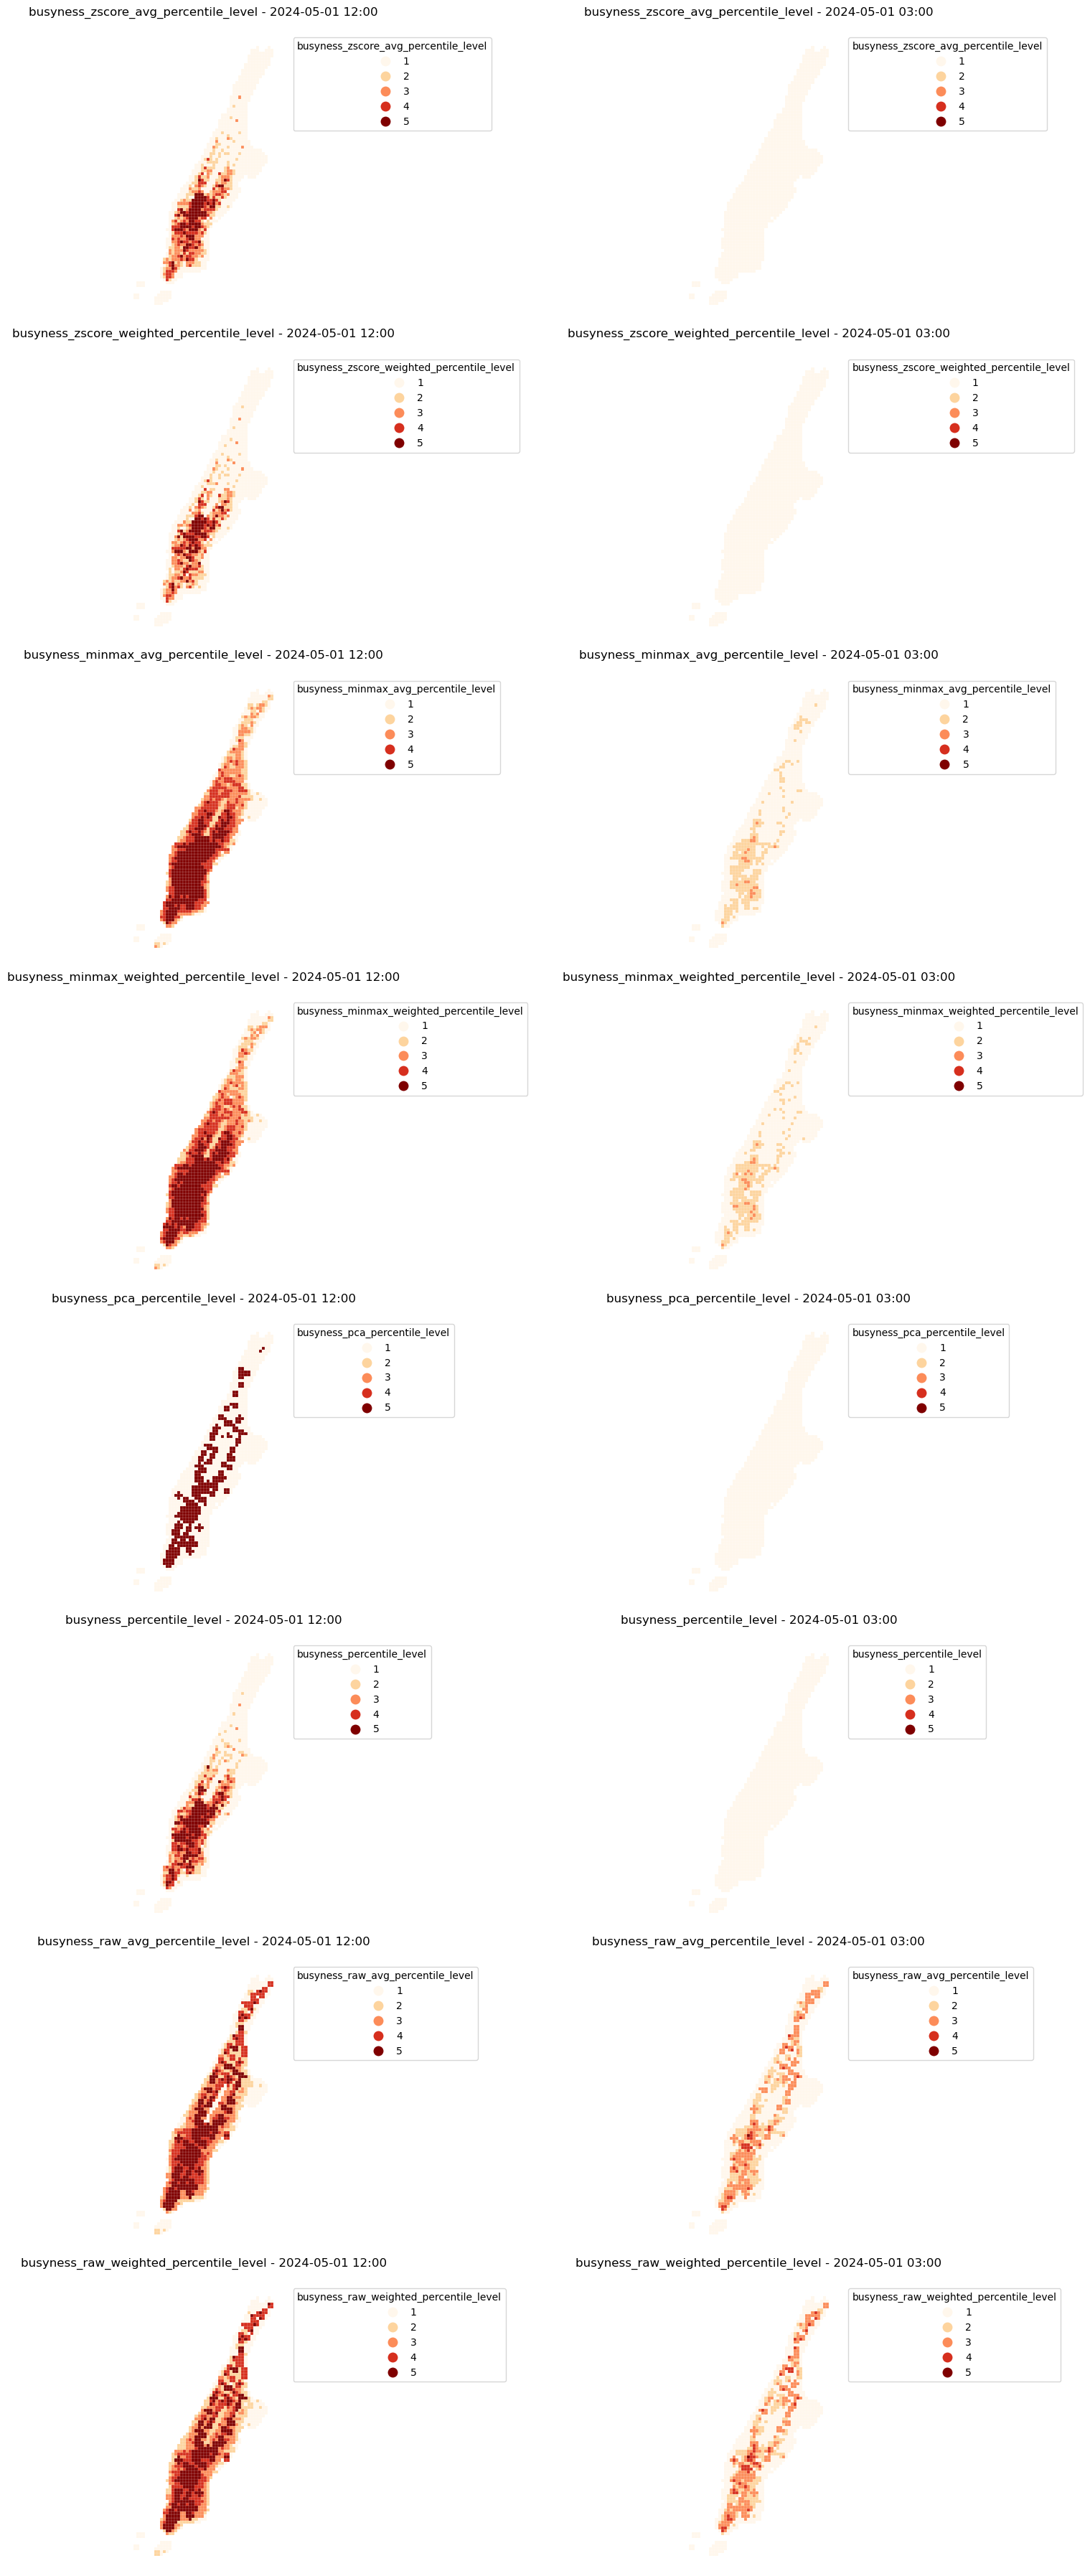

In [13]:
fig, axes = plt.subplots(8, 2, figsize=(18, 36))
i = 0
for col in busyness_percentile_cols:    
    plot_busyness_percentile_map(combined_df, '2024-05-01', 12, f'{col}_level', ax=axes[i, 0])
    plot_busyness_percentile_map(combined_df, '2024-05-01', 3, f'{col}_level', ax=axes[i, 1])
    i += 1

plt.tight_layout()
plt.show()

# Compare LightGBM Performance

## Sample Dataset
- Compare LightGBM performance on a sample dataset using different busyness levels derived from various busyness percentile methods.
- Only `busyness_zscore_avg_percentile`, `busyness_zscore_weighted_percentile`, `busyness_percentile` are selected for evaluation on the sample dataset, as they are the only methods that produce reasonable spatial patterns on the heatmap.
    - busyness_zscore_avg_percentile
        - Accuracy       : 0.902
        - Precision Score: 0.764
        - Recall Score   : 0.758
        - F1 Score       : 0.761
    - busyness_zscore_weighted_percentile
        - Accuracy       : 0.909
        - Precision Score: 0.773
        - Recall Score   : 0.767
        - F1 Score       : 0.769
    - busyness_percentile
        - Accuracy       : 0.891
        - Precision Score: 0.745
        - Recall Score   : 0.738
        - F1 Score       : 0.741

- All methods show relatively strong performance on the sample dataset.

In [20]:
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    learning_rate=0.1,
    num_leaves=64,
    n_estimators=100,
    random_state=42
)

In [21]:
X_lgbm = X_origin

===
busyness_zscore_avg_percentile
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021322 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2144
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 17
[LightGBM] [Info] Start training from score -0.349683
[LightGBM] [Info] Start training from score -2.219466
[LightGBM] [Info] Start training from score -2.696115
[LightGBM] [Info] Start training from score -2.952427
[LightGBM] [Info] Start training from score -2.706929
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[

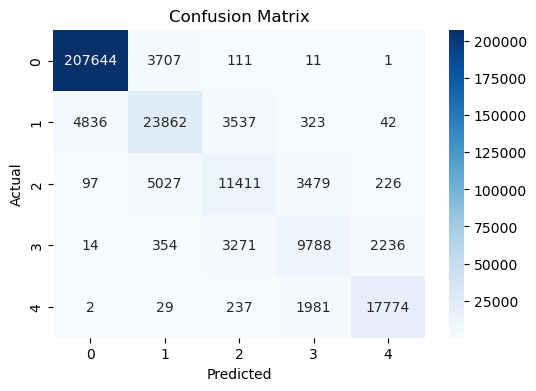


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    211474
           1       0.72      0.73      0.73     32600
           2       0.61      0.56      0.59     20240
           3       0.63      0.62      0.63     15663
           4       0.88      0.89      0.88     20023

    accuracy                           0.90    300000
   macro avg       0.76      0.76      0.76    300000
weighted avg       0.90      0.90      0.90    300000

===
busyness_zscore_weighted_percentile
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024516 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wi

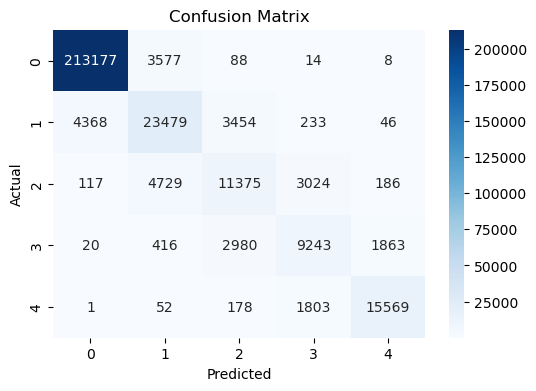


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    216864
           1       0.73      0.74      0.74     31580
           2       0.63      0.59      0.61     19431
           3       0.65      0.64      0.64     14522
           4       0.88      0.88      0.88     17603

    accuracy                           0.91    300000
   macro avg       0.77      0.77      0.77    300000
weighted avg       0.91      0.91      0.91    300000

===
busyness_percentile
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056591 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[Light

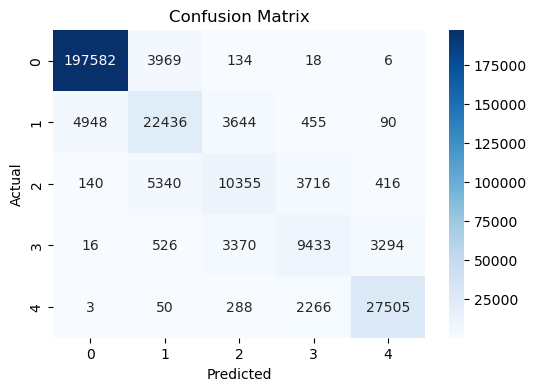


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98    201709
           1       0.69      0.71      0.70     31573
           2       0.58      0.52      0.55     19967
           3       0.59      0.57      0.58     16639
           4       0.88      0.91      0.90     30112

    accuracy                           0.89    300000
   macro avg       0.74      0.74      0.74    300000
weighted avg       0.89      0.89      0.89    300000



In [24]:
selected_percentile_cols = ['busyness_zscore_avg_percentile', 
                            'busyness_zscore_weighted_percentile', 
                            'busyness_percentile']

for col in selected_percentile_cols:
    print("===")
    print(col)
    y_lgbm = combined_df[f'{col}_level']
    y_lgbm = y_lgbm.astype(int) - 1
    
    predict_sample_dataset(model=lgbm_model,
                       input_X=X_lgbm,
                       input_y=y_lgbm,
                       sample_size=1000000,
                       y_type='categorical',
                       is_lgbm=True, 
                       eval_metric='multi_logloss')

## Full Dataset
- `busyness_zscore_avg_percentile`
    - Accuracy       : 0.916
    - Precision Score: 0.801
    - Recall Score   : 0.798
    - F1 Score       : 0.8
- `busyness_zscore_weighted_percentile`
    - Accuracy       : 0.922
    - Precision Score: 0.805
    - Recall Score   : 0.803
    - F1 Score       : 0.804
- `busyness_percentile`
    - Accuracy       : 0.906
    - Precision Score: 0.781
    - Recall Score   : 0.775
    - F1 Score       : 0.778
- `busyness_zscore_weighted_percentile` is selected as a target variable because:
    1.	Its heatmaps at both noon and 3 AM closely align with real-world expectations.
	2.	It achieves the best overall performance among the three compared methods.
	3.	While the assigned weights may be further refined, the weighted approach offers more interpretability than equal averaging — especially since some features represent actual counts (e.g., subway or bike stations within the grid), while others capture buffer-based estimates.

===
busyness_zscore_avg_percentile
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.237797 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2149
[LightGBM] [Info] Number of data points in the train set: 6990480, number of used features: 17
[LightGBM] [Info] Start training from score -0.349744
[LightGBM] [Info] Start training from score -2.220175
[LightGBM] [Info] Start training from score -2.695677
[LightGBM] [Info] Start training from score -2.949384
[LightGBM] [Info] Start training from score -2.707958
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:


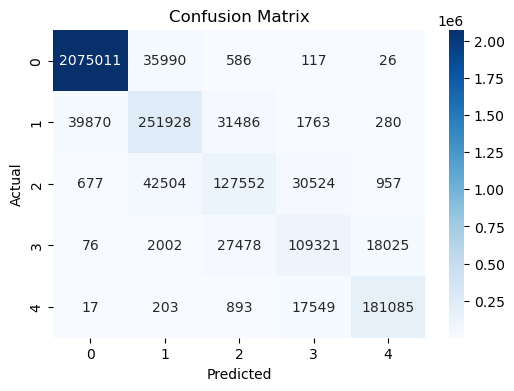


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98   2111730
           1       0.76      0.77      0.77    325327
           2       0.68      0.63      0.65    202214
           3       0.69      0.70      0.69    156902
           4       0.90      0.91      0.91    199747

    accuracy                           0.92   2995920
   macro avg       0.80      0.80      0.80   2995920
weighted avg       0.92      0.92      0.92   2995920

===
busyness_zscore_weighted_percentile
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.271479 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wi

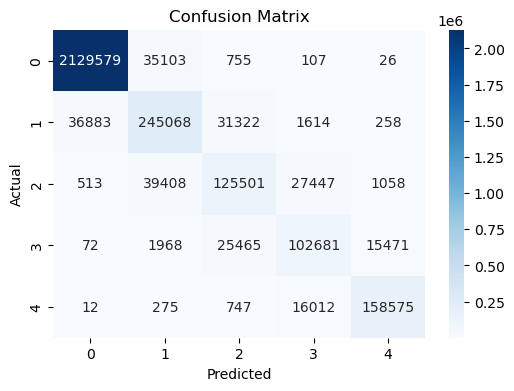


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98   2165570
           1       0.76      0.78      0.77    315145
           2       0.68      0.65      0.66    193927
           3       0.69      0.70      0.70    145657
           4       0.90      0.90      0.90    175621

    accuracy                           0.92   2995920
   macro avg       0.81      0.80      0.80   2995920
weighted avg       0.92      0.92      0.92   2995920

===
busyness_percentile
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.193892 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[Light

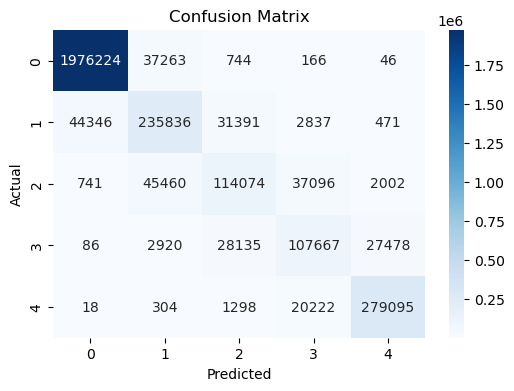


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98   2014443
           1       0.73      0.75      0.74    314881
           2       0.65      0.57      0.61    199373
           3       0.64      0.65      0.64    166286
           4       0.90      0.93      0.92    300937

    accuracy                           0.91   2995920
   macro avg       0.78      0.78      0.78   2995920
weighted avg       0.90      0.91      0.90   2995920



In [25]:
cat_features = X_lgbm.select_dtypes('category').columns.tolist()

for col in selected_percentile_cols:
    print("===")
    print(col)
    y_lgbm = combined_df[f'{col}_level']
    y_lgbm = y_lgbm.astype(int) - 1
    
    X_train_lgbm, X_test_lgbm, y_train_lgbm, y_test_lgbm = train_test_split(X_lgbm, y_lgbm, test_size=0.3, stratify=y_lgbm, random_state=42)

    lgbm_model = lgb.LGBMClassifier(
            objective='multiclass',
            num_class=5,
            learning_rate=0.1,
            num_leaves=64,
            n_estimators=100,
            random_state=42
        )
    
    lgbm_model.fit(
        X_train_lgbm, y_train_lgbm,
        eval_set=[(X_test_lgbm, y_test_lgbm)],
        eval_metric='multi_logloss',
        categorical_feature=cat_features,
        callbacks=[lgb.early_stopping(10)]
    )
    
    y_pred_lgbm = lgbm_model.predict(X_test_lgbm)
    classification_evaluation(y_test_lgbm, y_pred_lgbm)

# Improve Model

## Baseline
- `busyness_zscore_weighted_percentile_level` as target variable
    - Accuracy       : 0.909
    - Precision Score: 0.773
    - Recall Score   : 0.767
    - F1 Score       : 0.769

In [18]:
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    learning_rate=0.1,
    num_leaves=64,
    n_estimators=100,
    random_state=42
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020180 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2146
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 17
[LightGBM] [Info] Start training from score -0.324514
[LightGBM] [Info] Start training from score -2.251254
[LightGBM] [Info] Start training from score -2.736891
[LightGBM] [Info] Start training from score -3.028137
[LightGBM] [Info] Start training from score -2.835705
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.225

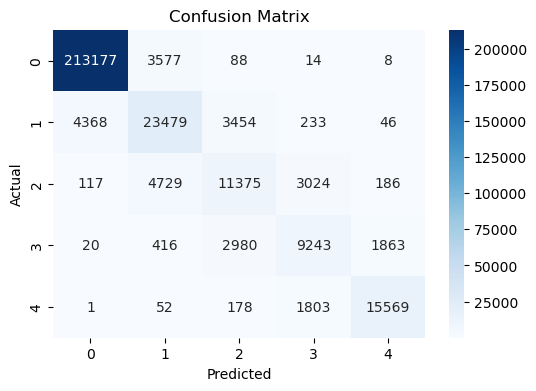


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    216864
           1       0.73      0.74      0.74     31580
           2       0.63      0.59      0.61     19431
           3       0.65      0.64      0.64     14522
           4       0.88      0.88      0.88     17603

    accuracy                           0.91    300000
   macro avg       0.77      0.77      0.77    300000
weighted avg       0.91      0.91      0.91    300000



In [19]:
y_lgbm = combined_df['busyness_zscore_weighted_percentile_level']
y_lgbm = y_lgbm.astype(int) - 1

predict_sample_dataset(model=lgbm_model,
                   input_X=X_lgbm,
                   input_y=y_lgbm,
                   sample_size=1000000,
                   y_type='categorical',
                   is_lgbm=True, 
                   eval_metric='multi_logloss')

## Remove irrelevant features
- Doesn't enhance performance 

In [20]:
# 2. Get feature importance
importances = lgbm_model.feature_importances_
features = X_lgbm.columns
importance_df = pd.DataFrame({'feature': features, 'importance': importances})

In [21]:
importance_df = importance_df.sort_values(by='importance', ascending=False)
importance_df['importance_pct'] = importance_df['importance'] / importance_df['importance'].sum(axis=0)
importance_df

,feature,importance,importance_pct
11,grid_id,17207,0.5463
5,hour,4697,0.1491
1,weekofyear,4310,0.1368
4,day,1666,0.0529
3,is_weekend,1071,0.0340
2,dayofweek,870,0.0276
12,restaurant_count,445,0.0141
7,temp_c,384,0.0122
14,lat,230,0.0073
15,lon,148,0.0047


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005761 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1416
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 8
[LightGBM] [Info] Start training from score -0.324514
[LightGBM] [Info] Start training from score -2.251254
[LightGBM] [Info] Start training from score -2.736891
[LightGBM] [Info] Start training from score -3.028137
[LightGBM] [Info] Start training from score -2.835705
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.2288

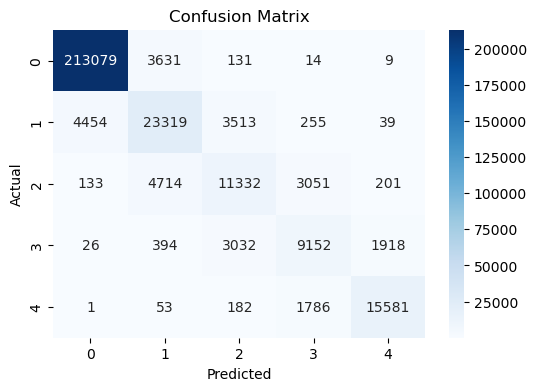


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    216864
           1       0.73      0.74      0.73     31580
           2       0.62      0.58      0.60     19431
           3       0.64      0.63      0.64     14522
           4       0.88      0.89      0.88     17603

    accuracy                           0.91    300000
   macro avg       0.77      0.76      0.77    300000
weighted avg       0.91      0.91      0.91    300000



In [22]:
selected_features = importance_df[importance_df['importance_pct'] > 0.01]['feature'].to_list()

predict_sample_dataset(model=lgbm_model,
                   input_X=X_lgbm[selected_features],
                   input_y=y_lgbm,
                   sample_size=1000000,
                   y_type='categorical',
                   is_lgbm=True, 
                   eval_metric='multi_logloss')

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009262 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1238
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 4
[LightGBM] [Info] Start training from score -0.324514
[LightGBM] [Info] Start training from score -2.251254
[LightGBM] [Info] Start training from score -2.736891
[LightGBM] [Info] Start training from score -3.028137
[LightGBM] [Info] Start training from score -2.835705
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.280398
Accuracy       : 0.883
Precision Score: 0.711
Recall Score   

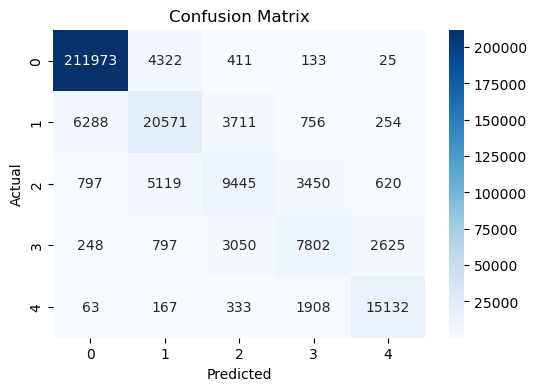


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97    216864
           1       0.66      0.65      0.66     31580
           2       0.56      0.49      0.52     19431
           3       0.56      0.54      0.55     14522
           4       0.81      0.86      0.83     17603

    accuracy                           0.88    300000
   macro avg       0.71      0.70      0.71    300000
weighted avg       0.88      0.88      0.88    300000



In [23]:
selected_features = importance_df[importance_df['importance_pct'] > 0.05]['feature'].to_list()

predict_sample_dataset(model=lgbm_model,
                   input_X=X_lgbm[selected_features],
                   input_y=y_lgbm,
                   sample_size=1000000,
                   y_type='categorical',
                   is_lgbm=True, 
                   eval_metric='multi_logloss')

## Refine model 1
- Slightly improved on sample dataset
    - Accuracy       : 0.911
    - Precision Score: 0.775
    - Recall Score   : 0.770
    - F1 Score       : 0.772
- But the performance doesn't work better on the full dataset
    - Accuracy       : 0.903
    - Precision Score: 0.775
    - Recall Score   : 0.769
    - F1 Score       : 0.771

In [24]:
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    learning_rate=0.05,            # ↓ 降低學習率，模型會更穩健但需更多樹
    num_leaves=31,                 # ↓ 適中複雜度，避免過擬合；可以配合 max_depth
    max_depth=7,                   # ↑ 控制深度，避免太深（overfitting）
    n_estimators=500,             # ↑ 搭配較低 learning_rate，多訓練幾棵樹
    subsample=0.8,                # ↑ 隨機抽樣資料行，防止 overfitting
    colsample_bytree=0.8,         # ↑ 隨機抽樣特徵列，提升泛化能力
    reg_alpha=0.1,                # ↑ L1 正則化
    reg_lambda=0.1,               # ↑ L2 正則化
    random_state=42
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019466 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2146
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 17
[LightGBM] [Info] Start training from score -0.324514
[LightGBM] [Info] Start training from score -2.251254
[LightGBM] [Info] Start training from score -2.736891
[LightGBM] [Info] Start training from score -3.028137
[LightGBM] [Info] Start training from score -2.835705
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

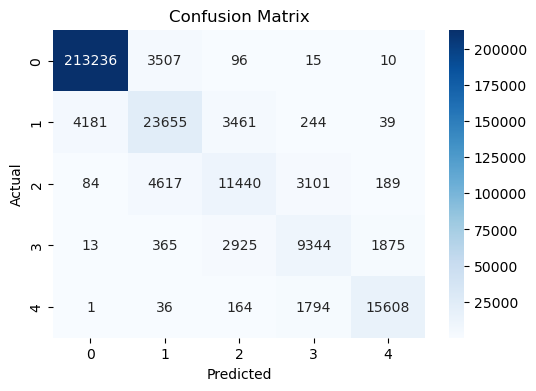


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    216864
           1       0.74      0.75      0.74     31580
           2       0.63      0.59      0.61     19431
           3       0.64      0.64      0.64     14522
           4       0.88      0.89      0.88     17603

    accuracy                           0.91    300000
   macro avg       0.77      0.77      0.77    300000
weighted avg       0.91      0.91      0.91    300000



In [25]:
predict_sample_dataset(model=lgbm_model,
                   input_X=X_lgbm,
                   input_y=y_lgbm,
                   sample_size=1000000,
                   y_type='categorical',
                   is_lgbm=True, 
                   eval_metric='multi_logloss')

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.236841 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2148
[LightGBM] [Info] Number of data points in the train set: 6990480, number of used features: 17
[LightGBM] [Info] Start training from score -0.396908
[LightGBM] [Info] Start training from score -2.252814
[LightGBM] [Info] Start training from score -2.709826
[LightGBM] [Info] Start training from score -2.891299
[LightGBM] [Info] Start training from score -2.298106
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

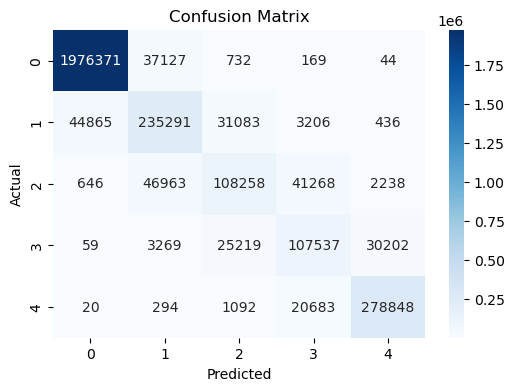


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98   2014443
           1       0.73      0.75      0.74    314881
           2       0.65      0.54      0.59    199373
           3       0.62      0.65      0.63    166286
           4       0.89      0.93      0.91    300937

    accuracy                           0.90   2995920
   macro avg       0.77      0.77      0.77   2995920
weighted avg       0.90      0.90      0.90   2995920



In [26]:
lgbm_model.fit(
    X_train_lgbm, y_train_lgbm,
    eval_set=[(X_test_lgbm, y_test_lgbm)],
    eval_metric='multi_logloss',
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(10)]
)

y_pred_lgbm = lgbm_model.predict(X_test_lgbm)
classification_evaluation(y_test_lgbm, y_pred_lgbm)

## Refine model 2
Use Optuna to search for the best hyperparameter combination.

The code block is commented out because the search took around 75 minutes to run.

The trial output has been saved to the file "optuna_trial_log.txt" for reference.

- The performance improves on full dataset, acheiving:
    - Accuracy       : 0.936
    - Precision Score: 0.84
    - Recall Score   : 0.839
    - F1 Score       : 0.84

In [ ]:
# import optuna
# import lightgbm as lgb
# from lightgbm import early_stopping, log_evaluation
# from optuna.integration import LightGBMPruningCallback
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report


# X_train_lgbm, X_valid_lgbm, y_train_lgbm, y_valid_lgbm = train_test_split(
#     X_lgbm, y_lgbm, test_size=0.3, stratify=y_lgbm, random_state=42
# )

# train_data = lgb.Dataset(X_train_lgbm, label=y_train_lgbm, categorical_feature=cat_features)
# valid_data = lgb.Dataset(X_valid_lgbm, label=y_valid_lgbm, categorical_feature=cat_features)

# # Define the objective function for Optuna optimization
# # It returns the validation multi_logloss for a given set of hyperparameters
# # Optuna will explore different combinations of these parameters to minimize the loss
# def objective(trial):
#     params = {
#         'objective': 'multiclass',
#         'num_class': 5,
#         'metric': 'multi_logloss',
#         'verbosity': -1,
#         'boosting_type': 'gbdt',
#         'feature_pre_filter': False,
#         'learning_rate': trial.suggest_float("learning_rate", 0.01, 0.1),
#         'num_leaves': trial.suggest_int("num_leaves", 31, 128),
#         'max_depth': trial.suggest_int("max_depth", 5, 12),
#         'reg_alpha': trial.suggest_float("reg_alpha", 0.0, 1.0),
#         'reg_lambda': trial.suggest_float("reg_lambda", 0.0, 1.0),
#         'subsample': trial.suggest_float("subsample", 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float("colsample_bytree", 0.6, 1.0),
#         'min_child_samples': trial.suggest_int("min_child_samples", 10, 100),
#         'seed': 42,
#     }

#     gbm = lgb.train(
#         params,
#         train_set=train_data,
#         valid_sets=[train_data, valid_data],
#         valid_names=['train', 'valid'],
#         num_boost_round=300,  # 300 trees at most
#         callbacks=[
#             early_stopping(10),
#             log_evaluation(20),
#             LightGBMPruningCallback(trial, "multi_logloss", valid_name="valid")
#         ]
#     )

#     score = gbm.best_score["valid"]["multi_logloss"]
#     print(f"Trial {trial.number} finished | logloss = {score:.5f} | params = {trial.params}")
#     return score

# import sys
# sys.stdout = open("optuna_trial_log.txt", "w")

# # Hyperparameter optimization (try up to 15 combinations)
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=10)

# # Print best trial
# print("\n🌟 Best trial:")
# print(f"  Score : {study.best_value:.5f}")
# print(f"  Params: {study.best_trial.params}")

# # Retrain LGBMClassifier with best params
# best_params = study.best_trial.params
# best_params.update({
#     'objective': 'multiclass',
#     'num_class': 5,
#     'metric': 'multi_logloss',
#     'boosting_type': 'gbdt',
#     'verbosity': -1,
#     'seed': 42,
# })

# sys.stdout.close()
# sys.stdout = sys.__stdout__


In [ ]:
import pandas as pd
import ast
import re

rows = []

with open("optuna_trial_log.txt", "r") as f:
    for line in f:
        if line.startswith("Trial ") and "finished | logloss =" in line:
            # Extract Trial no、logloss、params 
            match = re.match(r"Trial (\d+) finished \| logloss = ([\d.]+) \| params = (.+)", line.strip())
            if match:
                trial_id = int(match.group(1))
                logloss = float(match.group(2))
                params = ast.literal_eval(match.group(3))  # string->dict
                params["trial"] = trial_id
                params["logloss"] = logloss
                rows.append(params)

df_trials = pd.DataFrame(rows)


In [ ]:
# In the 10 trials, Trial 5 pruned. As a result, 9 trials show in the table.
df_trials

,learning_rate,num_leaves,max_depth,reg_alpha,reg_lambda,subsample,colsample_bytree,min_child_samples,trial,logloss
0,0.083591,103,5,0.426129,0.773584,0.665024,0.791178,29,0,0.23411
1,0.037469,50,5,0.067040,0.093011,0.655121,0.678784,41,1,0.28540
2,0.049161,105,5,0.953007,0.565472,0.914155,0.996746,41,2,0.25309
3,0.058504,84,7,0.009594,0.840966,0.689004,0.718707,20,3,0.21750
4,0.065623,85,10,0.103435,0.321841,0.838281,0.885511,94,4,0.17493
5,0.092416,96,8,0.894203,0.812334,0.664907,0.720386,61,6,0.18045
6,0.090824,89,11,0.269609,0.855119,0.756383,0.766318,13,7,0.16462
7,0.092010,120,7,0.792672,0.551760,0.928220,0.771938,50,8,0.18545
8,0.090829,43,7,0.520952,0.301454,0.670704,0.751357,24,9,0.19563


Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's multi_logloss: 0.164618
Accuracy       : 0.936
Precision Score: 0.84
Recall Score   : 0.839
F1 Score       : 0.84



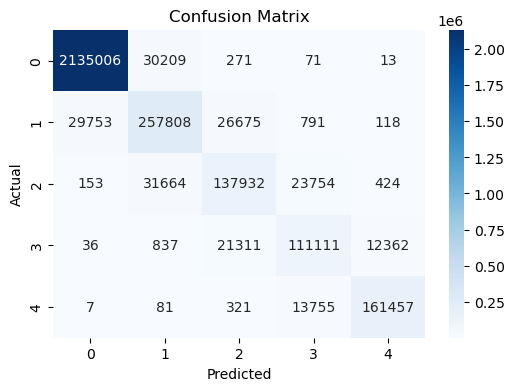


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99   2165570
           1       0.80      0.82      0.81    315145
           2       0.74      0.71      0.73    193927
           3       0.74      0.76      0.75    145657
           4       0.93      0.92      0.92    175621

    accuracy                           0.94   2995920
   macro avg       0.84      0.84      0.84   2995920
weighted avg       0.94      0.94      0.94   2995920



In [ ]:
cat_features = X_lgbm.select_dtypes('category').columns.tolist()

y_lgbm = combined_df['busyness_zscore_weighted_percentile_level']
y_lgbm = y_lgbm.astype(int) - 1

X_train_lgbm, X_test_lgbm, y_train_lgbm, y_test_lgbm = train_test_split(X_lgbm, y_lgbm, test_size=0.3, stratify=y_lgbm, random_state=42)

lgbm_model_tuned = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    learning_rate=0.0908235899987379,
    num_leaves=89,
    max_depth=11,
    reg_alpha=0.2696085210045166,
    reg_lambda=0.8551191768602961,
    subsample=0.7563826076605545,
    colsample_bytree=0.7663179669357703,
    min_child_samples=13,
    n_estimators=300,
    random_state=42
)

lgbm_model_tuned.fit(
    X_train_lgbm, y_train_lgbm,
    eval_set=[(X_test_lgbm, y_test_lgbm)],
    eval_metric='multi_logloss',
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(10)]
)

y_pred_tuned = lgbm_model_tuned.predict(X_test_lgbm)
classification_evaluation(y_test_lgbm, y_pred_tuned)

## Refine model 3
Keep the other params the same, increase n_estimators from 100 to 300

- The performance improves on the full dataset
    - Accuracy       : 0.936
    - Precision Score: 0.842
    - Recall Score   : 0.841
    - F1 Score       : 0.841

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's multi_logloss: 0.16136
Accuracy       : 0.936
Precision Score: 0.842
Recall Score   : 0.841
F1 Score       : 0.841



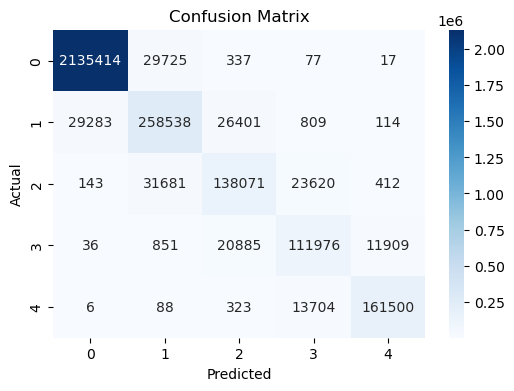


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99   2165570
           1       0.81      0.82      0.81    315145
           2       0.74      0.71      0.73    193927
           3       0.75      0.77      0.76    145657
           4       0.93      0.92      0.92    175621

    accuracy                           0.94   2995920
   macro avg       0.84      0.84      0.84   2995920
weighted avg       0.94      0.94      0.94   2995920



In [ ]:
cat_features = X_lgbm.select_dtypes('category').columns.tolist()

y_lgbm = combined_df['busyness_zscore_weighted_percentile_level']
y_lgbm = y_lgbm.astype(int) - 1

X_train_lgbm, X_test_lgbm, y_train_lgbm, y_test_lgbm = train_test_split(X_lgbm, y_lgbm, test_size=0.3, stratify=y_lgbm, random_state=42)

lgbm_model = lgb.LGBMClassifier(
        objective='multiclass',
        num_class=5,
        learning_rate=0.1,
        num_leaves=64,
        n_estimators=300,
        random_state=42
    )

lgbm_model.fit(
    X_train_lgbm, y_train_lgbm,
    eval_set=[(X_test_lgbm, y_test_lgbm)],
    eval_metric='multi_logloss',
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(10)]
)

y_pred_lgbm = lgbm_model.predict(X_test_lgbm)
classification_evaluation(y_test_lgbm, y_pred_lgbm)

# Final dataset and model
- The model from step `refine model 3` was selected as the final model due to its superior overall performance, achieving:
    - Accuracy       : 0.936
    - Precision Score: 0.842
    - Recall Score   : 0.841
    - F1 Score       : 0.841

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.222025 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2145
[LightGBM] [Info] Number of data points in the train set: 6990480, number of used features: 17
[LightGBM] [Info] Start training from score -0.324568
[LightGBM] [Info] Start training from score -2.251974
[LightGBM] [Info] Start training from score -2.737526
[LightGBM] [Info] Start training from score -3.023747
[LightGBM] [Info] Start training from score -2.836679
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's multi_logloss: 0.16

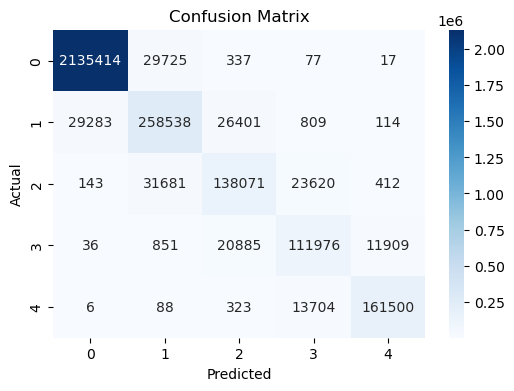


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99   2165570
           1       0.81      0.82      0.81    315145
           2       0.74      0.71      0.73    193927
           3       0.75      0.77      0.76    145657
           4       0.93      0.92      0.92    175621

    accuracy                           0.94   2995920
   macro avg       0.84      0.84      0.84   2995920
weighted avg       0.94      0.94      0.94   2995920



In [26]:
cat_features = X_lgbm.select_dtypes('category').columns.tolist()

y_lgbm = combined_df['busyness_zscore_weighted_percentile_level']
y_lgbm = y_lgbm.astype(int) - 1

X_train_lgbm, X_test_lgbm, y_train_lgbm, y_test_lgbm = train_test_split(X_lgbm, y_lgbm, test_size=0.3, stratify=y_lgbm, random_state=42)

lgbm_model = lgb.LGBMClassifier(
        objective='multiclass',
        num_class=5,
        learning_rate=0.1,
        num_leaves=64,
        n_estimators=300,
        random_state=42
    )

lgbm_model.fit(
    X_train_lgbm, y_train_lgbm,
    eval_set=[(X_test_lgbm, y_test_lgbm)],
    eval_metric='multi_logloss',
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(10)]
)

y_pred_lgbm = lgbm_model.predict(X_test_lgbm)
classification_evaluation(y_test_lgbm, y_pred_lgbm)

According to classification report, level 0 has the best performance, while level 2and level 3 apear weaker. with relatively lower precision and recall. This suggests the model has difficulty distinguishing between moderate levels of busyness.

Next, we may improve the classification performance of level 2 and 3 by refining features, adjusting class definitions, or tuning the model further.

## Cross validation

In [31]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Define StratifiedKFold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Run cross-validation
cv_results = cross_validate(
    lgbm_model,
    X_lgbm,
    y_lgbm,
    cv=skf,
    scoring={
        'accuracy': 'accuracy',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro',
        'f1_macro': 'f1_macro'
    },
    return_train_score=True,
    n_jobs=-1  # Use all available cores to speed up
)
cv_results

{'fit_time': array([677.23134422, 820.9655087 , 676.86485243]),
 'score_time': array([398.08664823, 477.63445449, 388.06042767]),
 'test_accuracy': array([0.9364708 , 0.93644346, 0.93608207]),
 'train_accuracy': array([0.94712028, 0.94685713, 0.94721326]),
 'test_precision_macro': array([0.84205531, 0.8414723 , 0.84091719]),
 'train_precision_macro': array([0.86966824, 0.86903107, 0.86942245]),
 'test_recall_macro': array([0.84139915, 0.84097732, 0.84016552]),
 'train_recall_macro': array([0.86885426, 0.86815488, 0.86859671]),
 'test_f1_macro': array([0.84162405, 0.84111672, 0.84046431]),
 'train_f1_macro': array([0.86916514, 0.86848373, 0.86893587])}

The model shows strong and consistent performance across 3-fold Stratified Cross-Validation, with an average accuracy around 0.936 and macro F1 score around 0.841. The small gap between training and test scores suggests good generalization with minimal overfitting. These results validate the robustness of the current hyperparameter setup and model structure.

In [32]:
import joblib

joblib.dump(lgbm_model, 'lgbm_model_v2.pkl')

['lgbm_model_v2.pkl']

In [ ]:
combined_df[['month', 'weekofyear', 'dayofweek', 'is_weekend', 'day', 'hour', 'is_holiday', # time
             'temp_c', 'dew_c', 'wind_speed_knot', 'precip_mm', # weather
             'grid_id', 'restaurant_count', 'population', # grid info
             'lat', 'lon',
             'event_count',
             'busyness_zscore_weighted_percentile', 'busyness_zscore_weighted_percentile_level' # target
            ]].to_pickle('final_model_dataset.pkl')